# Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



In [2]:
db = pd.read_csv("crop_data.csv")
db.head()

,N,P,K,temperature,humidity,ph,rainfall,crop
0,102,80,45,35.55,60.80,8.32,194.20,Soybean
1,92,13,195,24.51,37.72,4.70,79.80,Sugarcane
2,14,8,32,34.39,51.52,7.80,59.12,Cotton
3,106,39,0,39.11,87.03,6.04,63.19,Wheat
4,71,65,146,20.09,47.93,6.65,258.54,Barley


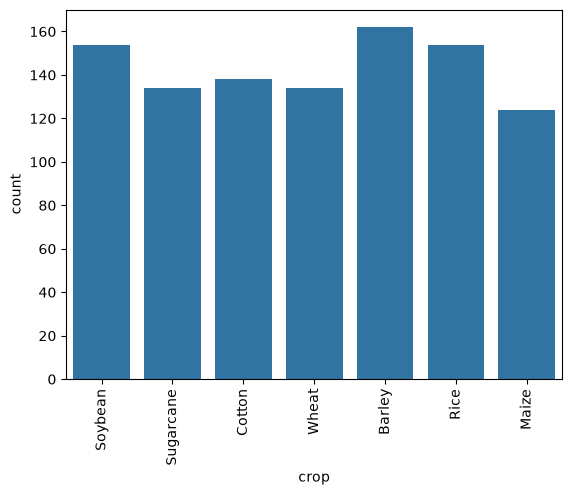

In [3]:
sns.countplot(data=db,x="crop")
plt.xticks(rotation=90)
plt.show()

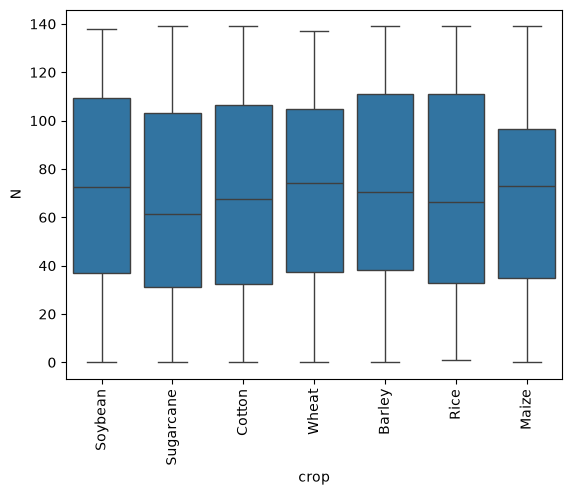

In [30]:
sns.boxplot(data=db,x='crop',y='N')
plt.xticks(rotation=90)
plt.show()

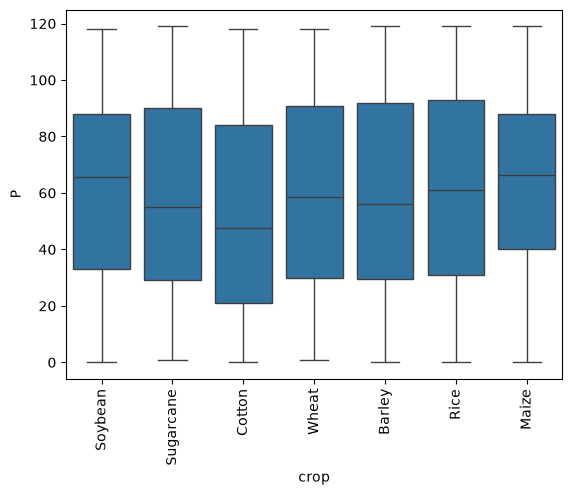

In [31]:
sns.boxplot(data=db,x='crop',y='P')
plt.xticks(rotation=90)
plt.show()

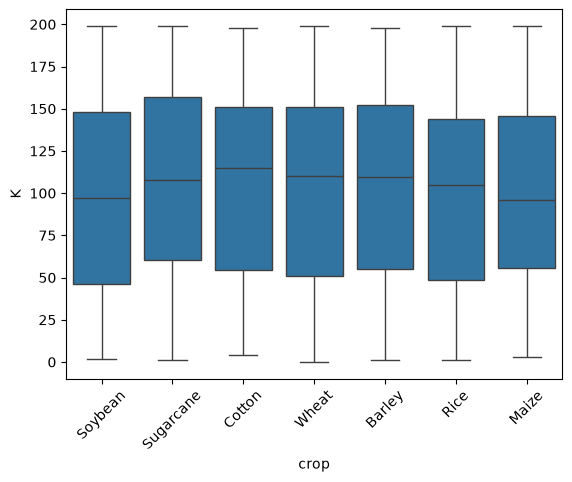

In [32]:
sns.boxplot(data=db,x='crop',y='K')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='temperature', ylabel='humidity'>

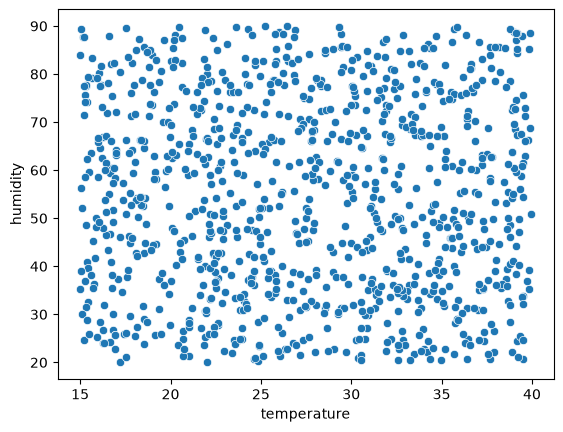

In [35]:
sns.scatterplot(data=db,x='temperature',y='humidity')


<Axes: >

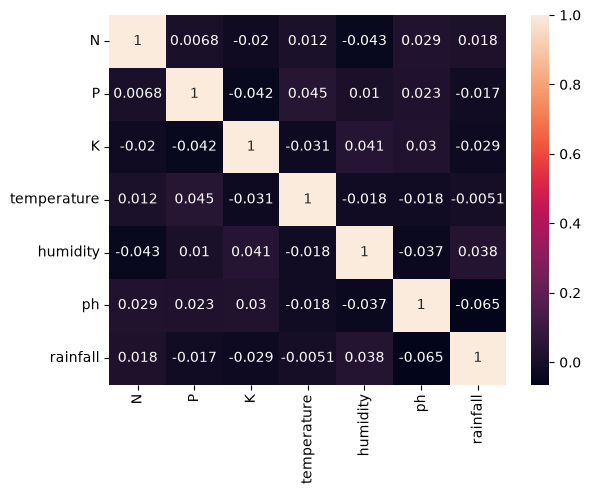

In [36]:
corr = db.corr(numeric_only=True)

sns.heatmap(corr,annot=True)


<Axes: xlabel='rainfall', ylabel='Count'>

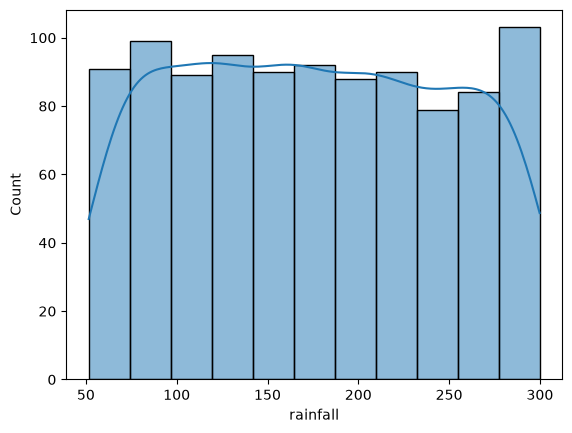

In [37]:
sns.histplot(data=db,x='rainfall',kde=True)

In [4]:

X = db.drop('crop',axis=1)
y = db['crop']


model = LogisticRegression(max_iter=10000)
encoder = LabelEncoder()

y = encoder.fit_transform(db['crop'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)

model.fit(X_train,y_train)
predictions = model.predict(X_test)


score = accuracy_score(y_test,predictions)
print("Accuracy : ", score)

training_accuracy = model.score(X_train,y_train)
testing_accuracy = model.score(X_test,y_test)

print("Training Accuracy : ", training_accuracy)
print("Testing Accuracy : ", testing_accuracy)

Accuracy :  0.125
Training Accuracy :  0.1875
Testing Accuracy :  0.125


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,predictions)
print(cm)

[[ 7  4  3 11  4  3  4]
 [12  5  1  9  2  0  1]
 [ 9  4  0 12  0  1  1]
 [ 6  3  2 10  2  1  2]
 [11  3  2  8  1  3  0]
 [ 8  3  6  6  4  1  1]
 [ 7  3  1  6  2  4  1]]


Text(0.5, 1.0, 'Confusion matrix')

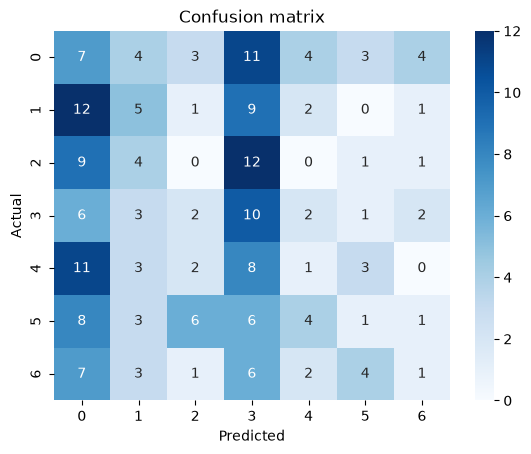

In [9]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")

plt.show

In [15]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

ps = precision_score(y_test,predictions,average="weighted")
rs = recall_score(y_test,predictions,average="weighted")
fs = f1_score(y_test,predictions,average="weighted")
a_s = accuracy_score(y_test,predictions)
print("Precision Score : ", ps)
print("Recall Score : ", rs)
print("F1_score : ",fs)
print("accuracy_score : ",a_s)

Precision Score :  0.10445492142266335
Recall Score :  0.125
F1_score :  0.10354339515933221
accuracy_score :  0.125


In [14]:
from sklearn.metrics import classification_report

cr = classification_report(y_test,predictions)

print(cr)

              precision    recall  f1-score   support

           0       0.12      0.19      0.15        36
           1       0.20      0.17      0.18        30
           2       0.00      0.00      0.00        27
           3       0.16      0.38      0.23        26
           4       0.07      0.04      0.05        28
           5       0.08      0.03      0.05        29
           6       0.10      0.04      0.06        24

    accuracy                           0.12       200
   macro avg       0.10      0.12      0.10       200
weighted avg       0.10      0.12      0.10       200

